In [33]:
from typing import cast

import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt

import pandas as pd

# RMSE - среднеквадратичная ошибка
# RMSE = (1/n * sum(yi - Yi)^2)^0.5
# yi - наблюдаемые значения
# Yi - предсказанные значения
# MAE - средняя абсолютная ошибка
# MAE = sum(|yi-xi|) / n
# yi - прогноз
# xi - истинное значение
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [34]:
# Подобрать таблицу данных с несбалансированными классами.
# Решить задачу классификации любым подходящим методом.
import seaborn as sns
df = sns.load_dataset('diamonds')

train_df, test_df = train_test_split(df, test_size=0.2)

In [35]:
def evaluate(model, train_df, test_df):
    preds_train = model.predict(train_df.drop('price', axis=1))
    preds_test = model.predict(test_df.drop('price', axis=1))
    
    
    rmse_train = root_mean_squared_error(train_df['price'], preds_train)
    rmse_test = root_mean_squared_error(test_df['price'], preds_test)
    mae_train = mean_absolute_error(train_df['price'], preds_train)
    mae_test = mean_absolute_error(test_df['price'], preds_test)
    
    print(f'Train RMSE: {rmse_train}')
    print(f'Train MAE: {mae_train}')
    print(f'Test RMSE: {rmse_test}')
    print(f'Test MAE: {mae_test}')


In [36]:
from sklearn.linear_model import LinearRegression

train_non_cat_df = train_df.select_dtypes(exclude='category')
test_non_cat_df = test_df.select_dtypes(exclude='category')

model = LinearRegression()
model.fit(train_non_cat_df.drop('price', axis=1), train_non_cat_df['price'])

evaluate(model, train_non_cat_df, test_non_cat_df)


Train RMSE: 1496.7760457375089
Train MAE: 891.8081818770256
Test RMSE: 1497.39069854385
Test MAE: 888.4808633901855


Finished model with n_estimators=1800 and max_depth=2
Finished model with n_estimators=1700 and max_depth=2
Finished model with n_estimators=1600 and max_depth=2
Finished model with n_estimators=1500 and max_depth=2
Finished model with n_estimators=1400 and max_depth=2
Finished model with n_estimators=1300 and max_depth=2
Finished model with n_estimators=1200 and max_depth=2
Finished model with n_estimators=1100 and max_depth=2
Finished model with n_estimators=1000 and max_depth=2
Finished model with n_estimators=900 and max_depth=2
Finished model with n_estimators=800 and max_depth=2
Finished model with n_estimators=700 and max_depth=2
Finished model with n_estimators=600 and max_depth=2
Finished model with n_estimators=500 and max_depth=2
Finished model with n_estimators=400 and max_depth=2
Finished model with n_estimators=300 and max_depth=2
Finished model with n_estimators=200 and max_depth=2
Finished model with n_estimators=100 and max_depth=2
Finished model with n_estimators=1800

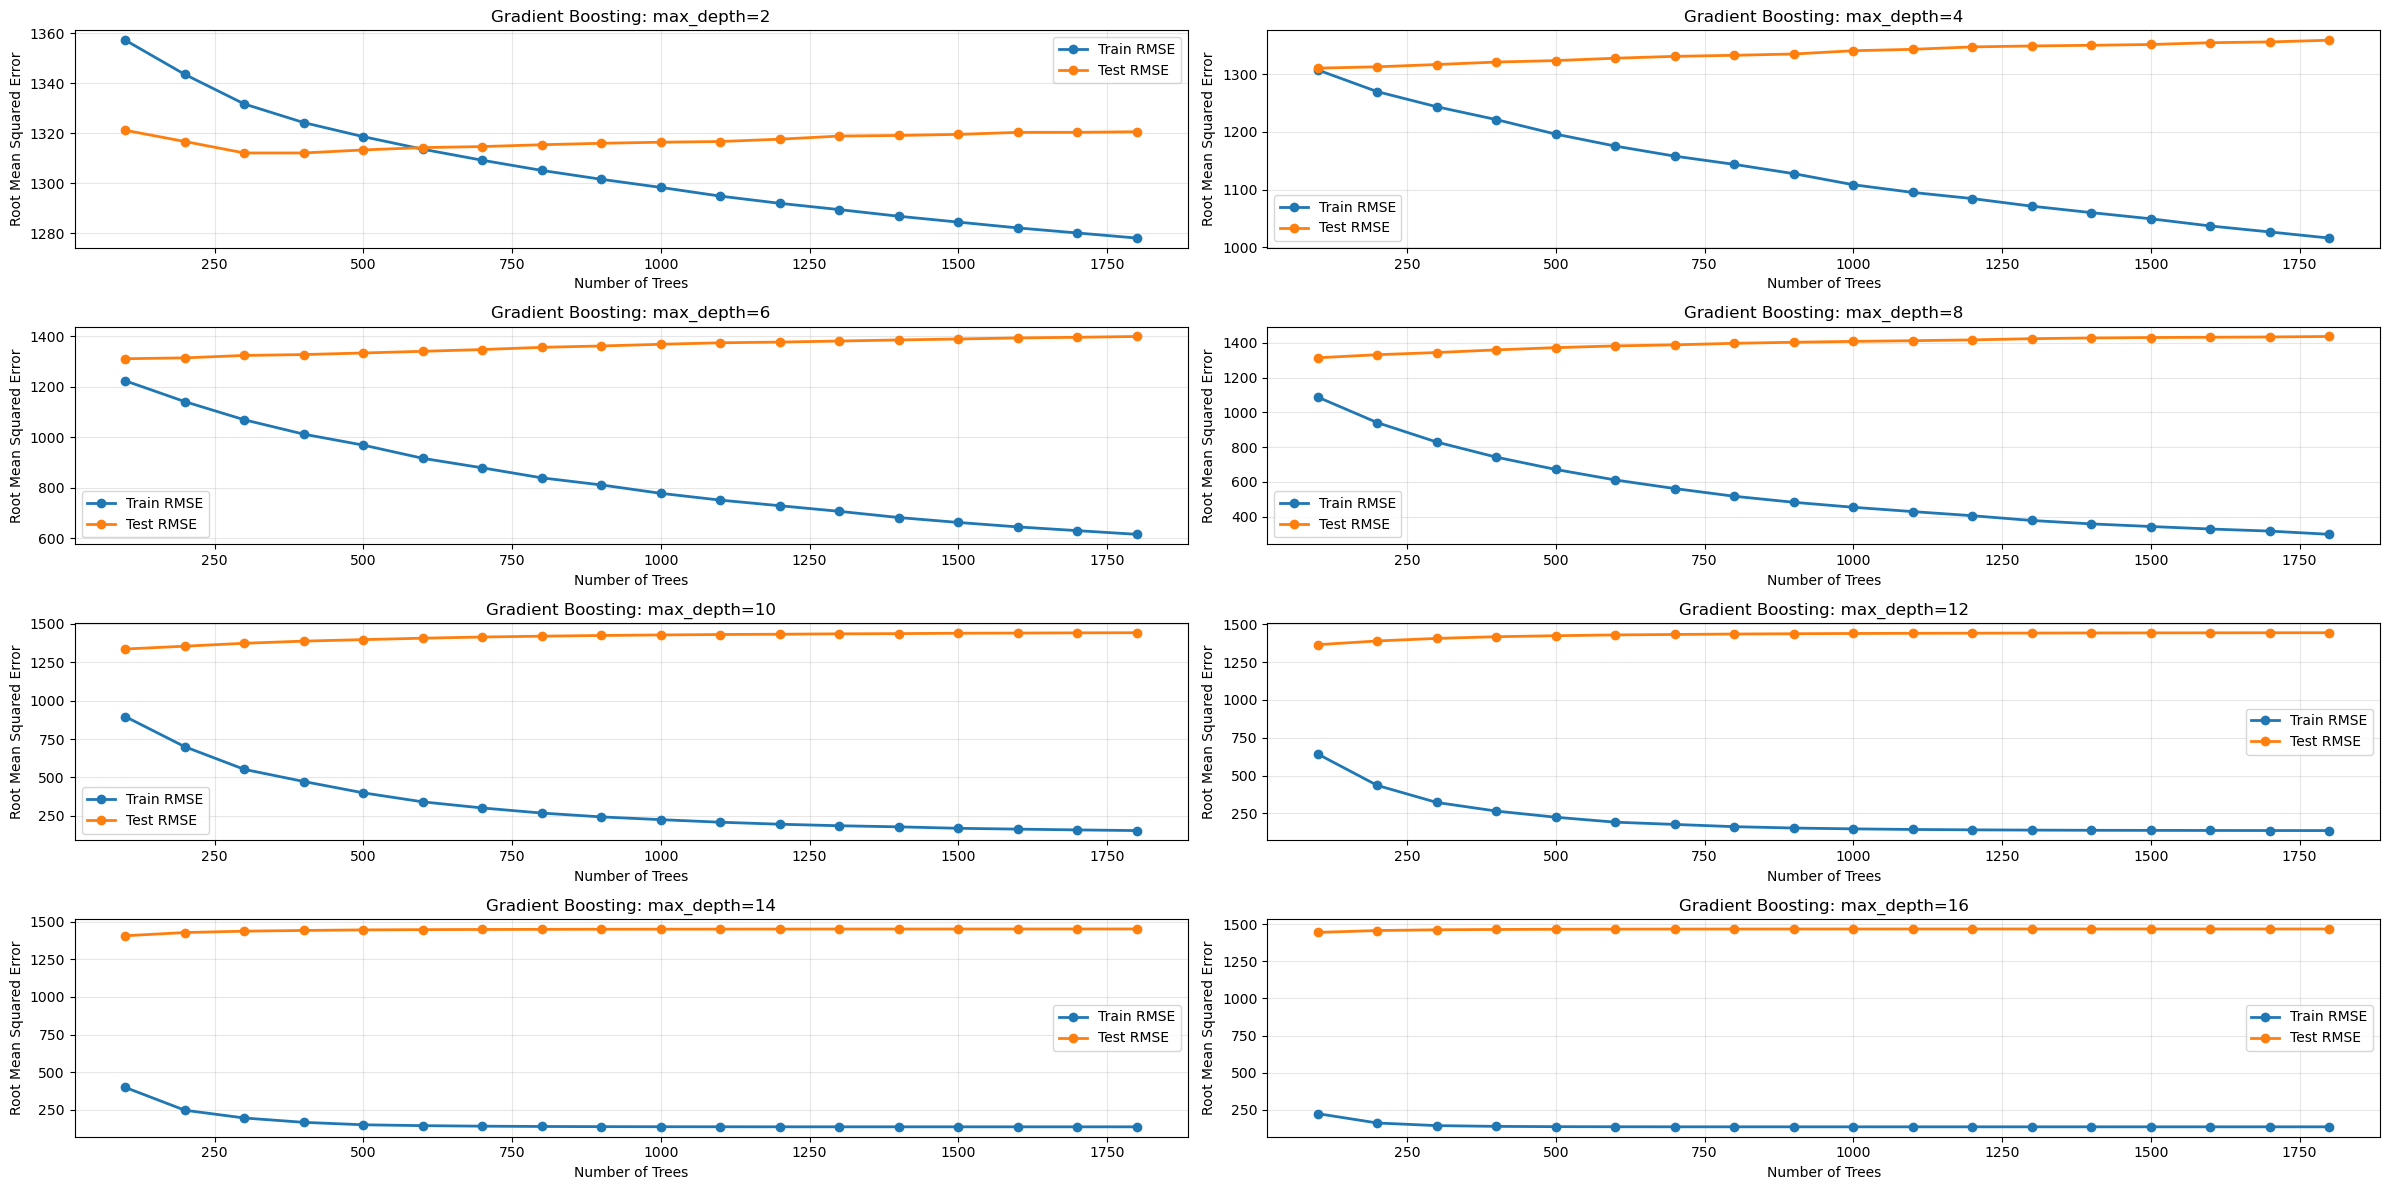

In [ ]:
# Построить решение методом бустинга (подобрать оптимальные параметры сложности).
# Сравнить с линейной регрессией.
from sklearn.ensemble import GradientBoostingRegressor

n_estimators_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800]
depths = [2, 4, 6, 8, 10, 12, 14, 16]

fig, axes = plt.subplots(4, 2, figsize=(24, 12))
axes = axes.flatten()

X_train = train_non_cat_df.drop('price', axis=1)
y_train = train_non_cat_df['price']
X_test = test_non_cat_df.drop('price', axis=1)
y_test = test_non_cat_df['price']


for depth, i in zip(depths, range(len(depths))):
    train_scores = []
    test_scores = []

    model = GradientBoostingRegressor(
        n_estimators=max(n_estimators_list), 
        max_depth=depth, 
        random_state=42
    )
    model.fit(X_train, y_train)
    
    all_train_predictions = list(model.staged_predict(X_train))
    all_test_predictions = list(model.staged_predict(X_test))

    for n_est in reversed(n_estimators_list):
        train_score = root_mean_squared_error(y_train, all_train_predictions[n_est-1])
        train_scores.append(train_score)
        test_score = root_mean_squared_error(y_test, all_test_predictions[n_est-1])
        test_scores.append(test_score)

        print(f"Finished model with n_estimators={n_est} and max_depth={depth}")


    train_scores.reverse()
    test_scores.reverse()

    axes[i].plot(n_estimators_list[:len(train_scores)], train_scores, marker='o', label='Train RMSE', linewidth=2)
    axes[i].plot(n_estimators_list[:len(test_scores)], test_scores, marker='o', label='Test RMSE', linewidth=2)
    axes[i].set_title(f'Gradient Boosting: max_depth={depth}')
    axes[i].set_xlabel('Number of Trees')
    axes[i].set_ylabel('Root Mean Squared Error')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [37]:
best_params = {
    "n_estimators": 700,
    "depth": 6
}

In [38]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["depth"],
    random_state=42
)

In [39]:
model.fit(train_non_cat_df.drop('price', axis=1), train_non_cat_df['price'])

evaluate(model, train_non_cat_df, test_non_cat_df)

Train RMSE: 870.4303083902164
Train MAE: 526.2841724096511
Test RMSE: 1376.8252401958127
Test MAE: 774.9417531651058


In [40]:
# Применить one hot и target encoding для категориальных признаков 
# (взять данные, где такие признаки есть). Сравнить точность.
train_df_te, test_df_te = train_df.copy(), test_df.copy()


cat_cols = df.select_dtypes(include='category').columns.to_list()

for col in cat_cols:
    mapping = train_df.groupby(col, observed=False)["price"].mean()
    train_df_te[col] = train_df_te[col].map(mapping)
    test_df_te[col] = test_df_te[col].map(mapping)

model.fit(train_df_te.drop('price', axis=1), train_df_te['price'])

evaluate(model, train_df_te, test_df_te)


Train RMSE: 276.38958841526534
Train MAE: 166.13596759613438
Test RMSE: 539.4580079777944
Test MAE: 265.701844417888


In [41]:
train_df_te, test_df_te = train_df.copy(), test_df.copy()

train_ohe_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_ohe_df  = pd.get_dummies(test_df,  columns=cat_cols, drop_first=True)

model.fit(train_ohe_df.drop('price', axis=1), train_ohe_df['price'])

evaluate(model, train_ohe_df, test_ohe_df)


Train RMSE: 337.83161563600385
Train MAE: 189.1090846105713
Test RMSE: 566.8657051043965
Test MAE: 278.21326814480295


In [45]:
model = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["depth"],
    random_state=42
)
print("GradientBoostingRegressor")
model.fit(train_non_cat_df.drop('price', axis=1), train_non_cat_df['price'])
evaluate(model, train_non_cat_df, test_non_cat_df)

model = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["depth"],
    random_state=42
)
print("target encoding")
train_df_te, test_df_te = train_df.copy(), test_df.copy()
cat_cols = df.select_dtypes(include='category').columns.to_list()
for col in cat_cols:
    mapping = train_df.groupby(col, observed=False)["price"].mean()
    train_df_te[col] = train_df_te[col].map(mapping)
    test_df_te[col] = test_df_te[col].map(mapping)
model.fit(train_df_te.drop('price', axis=1), train_df_te['price'])
evaluate(model, train_df_te, test_df_te)

model = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["depth"],
    random_state=42
)
print("ohe")
train_df_te, test_df_te = train_df.copy(), test_df.copy()
train_ohe_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_ohe_df  = pd.get_dummies(test_df,  columns=cat_cols, drop_first=True)
model.fit(train_ohe_df.drop('price', axis=1), train_ohe_df['price'])
evaluate(model, train_ohe_df, test_ohe_df)

GradientBoostingRegressor
Train RMSE: 870.4303083902164
Train MAE: 526.2841724096511
Test RMSE: 1376.8252401958127
Test MAE: 774.9417531651058
target encoding
Train RMSE: 276.38958841526534
Train MAE: 166.13596759613438
Test RMSE: 539.4580079777944
Test MAE: 265.701844417888
ohe
Train RMSE: 337.83161563600385
Train MAE: 189.1090846105713
Test RMSE: 566.8657051043965
Test MAE: 278.21326814480295


In [ ]:
# Визуализировать объекты (не обязательно для той же таблицы)
# в пространстве главных компонент.
train_df.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

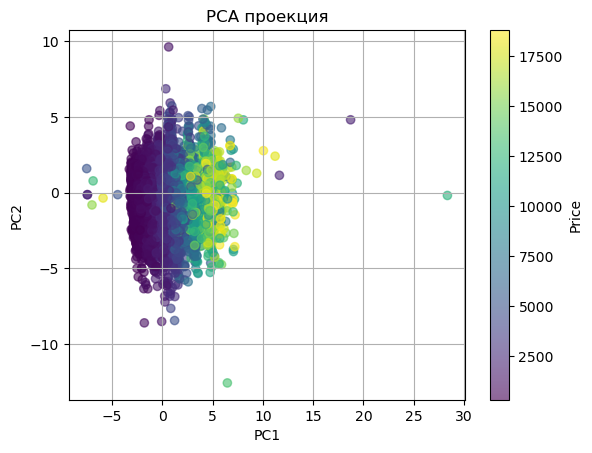

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_df_te.select_dtypes(exclude='category').drop(["price"], axis=1))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=train_df_te['price'], 
                     alpha=0.6, cmap='viridis')
plt.colorbar(scatter, label='Price')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA проекция")
plt.grid(True)
plt.show()